# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# inspect the dataset

In [2]:
df = pd.read_csv("humidity.csv")
df.head()

,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


In [3]:
import os
print(os.getcwd())

C:\Users\niraj\anaconda_projects\Task-1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


# Check the dataset shape

In [5]:
df.shape
# Means 701548 rows and 6 columns

(701548, 6)

In [6]:
df.columns
# display columns name

Index(['sensor_id', 'lat', 'lon', 'pressure', 'temperature', 'humidity'], dtype='object')

In [7]:
df.describe()
#It provides: Count,Mean,Standard Deviation,Minimum,25%,50% (Median),75%,Maximum

,sensor_id,lat,lon,pressure,temperature,humidity
count,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000
mean,2835.419842,42.679722,23.333739,94965.292500,24.754990,48.348949
std,798.018890,0.025568,0.039365,2577.210945,14.013001,20.907247
min,1764.000000,42.622000,23.240000,0.000000,-145.120000,0.000000
25%,2224.000000,42.665000,23.310000,94528.017500,20.630000,34.140000
50%,2323.000000,42.685000,23.332000,95005.480000,24.780000,48.350000
75%,3474.000000,42.694000,23.360000,95405.132500,29.870000,62.940000
max,4661.000000,42.738000,23.419000,164926.750000,61.170000,100.000000


# Exploratory Data Analysis (EDA)

In [8]:
df.isnull().sum()
# this command confirms the exact count for each column.

sensor_id      0
lat            0
lon            0
pressure       0
temperature    0
humidity       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(4035)

In [10]:
# Remove duplicate data and reset indexing
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df.duplicated().sum() # check duplicates again for verify

np.int64(0)

In [11]:
# new shape
df.shape

(697513, 6)

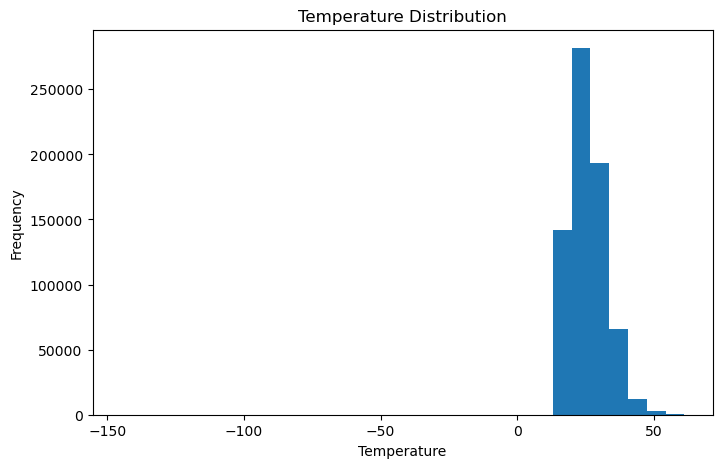

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["temperature"], bins=30)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

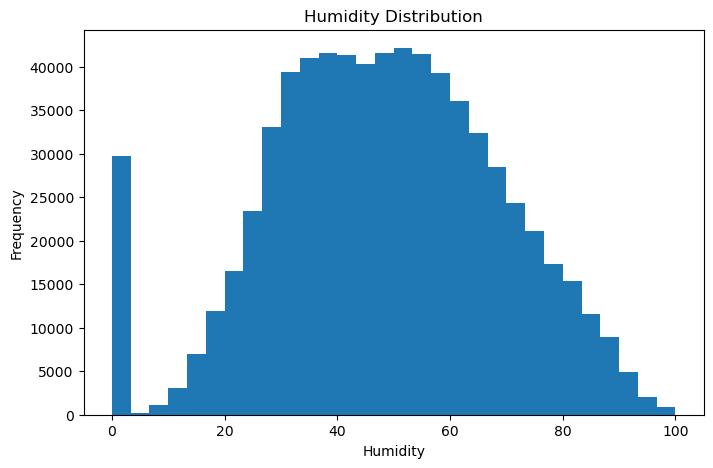

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df["humidity"], bins=30)
plt.title("Humidity Distribution")
plt.xlabel("Humidity")
plt.ylabel("Frequency")
plt.show()

# Relationship Between Humidity and Temperature

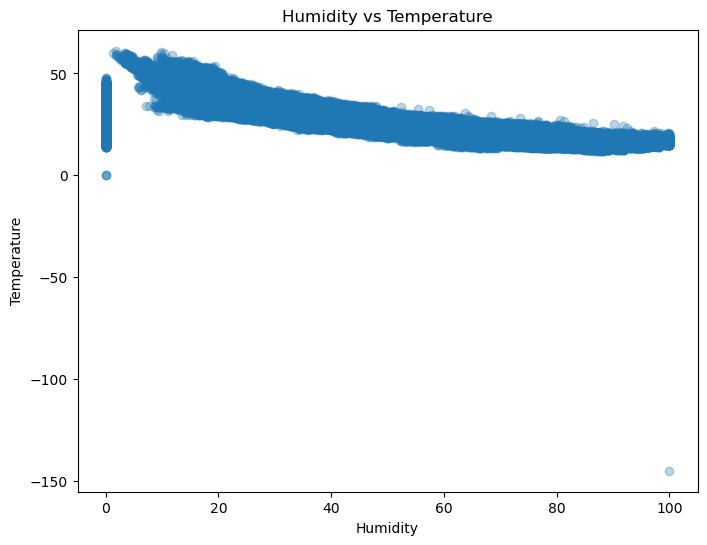

In [14]:
#Why did you create a scatter plot before training the model?

# A scatter plot helps visualize the relationship between the independent variable (humidity) and the dependent variable (temperature).
# It lets us see whether a linear trend exists and whether there are outliers before applying Linear Regression.

plt.figure(figsize=(8,6))

plt.scatter(df["humidity"], df["temperature"], alpha=0.3)

plt.title("Humidity vs Temperature")
plt.xlabel("Humidity")
plt.ylabel("Temperature")

plt.show()

# Feature Selection (X) and Target Selection (y)

In [15]:
# Create feature (X)
X = df[["humidity"]]
# create target (Y)
y = df["temperature"]

In [16]:
print(X.shape) # 2D table
print(y.shape) # 1D list

(697513, 1)
(697513,)


In [17]:
# Q. Why did you choose humidity as the feature?

# Answer:

# The task objective is to predict temperature based on humidity. Therefore, humidity is the independent variable (feature),
# and temperature is the dependent variable (target).

# Train-Test Split

# Split the Dataset

In [18]:
# A common split is: 80% for training , 20% for testing , For your dataset

In [19]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# verify the split

In [21]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (558010, 1)
X_test shape : (139503, 1)
y_train shape: (558010,)
y_test shape : (139503,)


In [22]:
# Q. Why do we split the dataset before training?

# Answer: We split the dataset so that the model learns from the training data and is evaluated on unseen testing data.
# This helps measure how well the model generalizes to new data instead of simply memorizing the training examples.

# Train the linear Regression model

In [23]:
# create the model (emoty)
model = LinearRegression()

# At this point: Model   Knowledge = 0 , Slope = Unknown , Intercept = Unknown

# Train the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
# View the Learned Parameters
print("Coefficient (Slope):", model.coef_)
print("Intercept:", model.intercept_)

Coefficient (Slope): [-0.24224729]
Intercept: 37.32421658552107


In [25]:
# Q. What is the difference between LinearRegression() and .fit()?

# Answer:

# LinearRegression() creates an empty model.
# .fit() trains the model using the training data and learns the relationship between the feature and the target.

In [26]:
# Q: What is the meaning of the coefficient?

# Answer:

# The coefficient represents the change in the predicted temperature for a one-unit increase in humidity.
# Since the coefficient is negative (-0.2422), the model predicts that temperature decreases by about 0.242°C for every 1% increase in humidity.

# Making Predictions and comparing actual temparature and predicted

In [27]:
# Predict temperature using the testing data
y_pred = model.predict(X_test)

In [28]:
# Compare the actual and predicted temperatures

comparison = pd.DataFrame({
    "Actual Temperature": y_test.values,
    "Predicted Temperature": y_pred
})

comparison["Difference"] = comparison["Actual Temperature"] - comparison["Predicted Temperature"]

comparison.head(10)

,Actual Temperature,Predicted Temperature,Difference
0,18.81,20.144038,-1.334038
1,21.68,24.397901,-2.717901
2,20.59,24.317959,-3.727959
3,22.29,23.019514,-0.729514
4,35.02,31.088771,3.931229
5,22.05,24.649838,-2.599838
6,27.99,25.175515,2.814485
7,26.98,28.392559,-1.412559
8,31.09,29.225890,1.864110
9,19.81,17.711876,2.098124


# Evaluate the Model (MAE, MSE, RMSE, R^2_score)

In [29]:
# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.7519934647169464


In [30]:
# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 16.79479422109516


In [31]:
# Root Mean Squared Error (RMSE)
import numpy as np

rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 4.098145217179982


In [32]:
# R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.597338043233451


# Print All evaluation togather

In [33]:
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 2.7519934647169464
Mean Squared Error (MSE): 16.79479422109516
Root Mean Squared Error (RMSE): 4.098145217179982
R² Score: 0.597338043233451


In [ ]:
# Q. Which metric is the most important?

# Answer is:

# MAE → Average prediction error in the original unit.
# MSE → Penalizes large errors more heavily.
# RMSE → Easier to interpret because it is in the same unit as the target.
# R² Score → Shows how well the model explains the variation in the data.

# Visualize the Regression Line

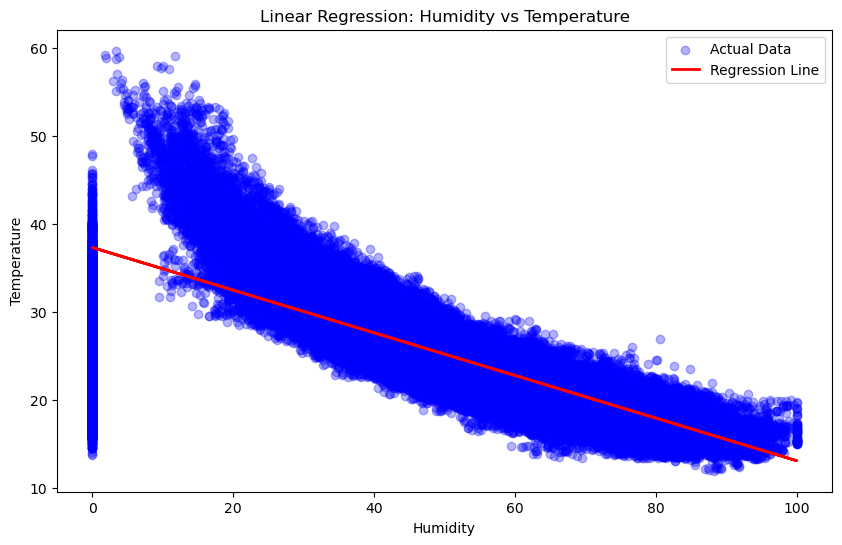

In [36]:
plt.figure(figsize=(10,6))

# Scatter plot of the actual data
plt.scatter(X_test, y_test,
            color="blue",
            alpha=0.3,
            label="Actual Data")

# Regression line
plt.plot(X_test,
         y_pred,
         color="red",
         linewidth=2,
         label="Regression Line")

plt.title("Linear Regression: Humidity vs Temperature")
plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.legend()

plt.show()

# Conclusion

# In this project, a Simple Linear Regression model was developed to predict temperature using humidity as the input feature.

# The dataset was explored, cleaned by removing duplicate records, and analyzed through Exploratory Data Analysis (EDA). After preparing the data, it was divided into training and testing sets, and the Linear Regression model was trained successfully.

# The model achieved the following performance:

# - Mean Absolute Error (MAE): **2.75°C**
# - Mean Squared Error (MSE): **16.79**
# - Root Mean Squared Error (RMSE): **4.10°C**
# - R² Score: **0.5973**

# These results indicate that the model can explain approximately **60% of the variation in temperature** using humidity alone. While the model provides reasonably accurate predictions, temperature is influenced by several other environmental factors such as pressure, latitude, longitude, wind speed, and atmospheric conditions.

# For improved prediction accuracy, future work could include:
# - Multiple Linear Regression using additional features.
# - Polynomial Regression to capture non-linear relationships.
# - Time Series forecasting models for temporal weather data.
# - Advanced Machine Learning algorithms such as Decision Trees, Random Forest, or Gradient Boosting.

# Overall, this project demonstrates the complete workflow of building, training, evaluating, and interpreting a Simple Linear Regression model using Python and Scikit-learn.